In [1]:
from funzioni_varie.function_extraction import *

from dotenv import load_dotenv

load_dotenv() # Load environment variables from .env file
api_key = os.getenv("GEMINI_API_KEY")

assert api_key is not None

SELEZIONE FILE:

In [2]:
#pdf_path = "IMU/Regolamento/Regolamento IMU L.160-2019 - agg. a DCC n. 75-2024.pdf"

#pdf_path = "IMU/Informativa trattamento dati/Informativa estesa- IMPOSTE LOCALI_rev.11-2023.pdf"

#pdf_path = "IMU/enc/imu-enc-istr-23-04.05.2023.pdf"
#pdf_path = "IMU/enc/decreto-ministeriale-04.05.2023-dichiarazione-imu-enc.pdf"

#pdf_path = "IMU/Aliquote/2025_05_06 Informativa IMU 2025 verificata.pdf"
#pdf_path = "IMU/Aliquote/Prospetto aliquote MEF 2025.pdf"
#pdf_path = "IMU/Aliquote/2024-06-03 Informativa IMU 2024.pdf"
#pdf_path = "IMU/Aliquote/2024-04-19 Prospetto aliquote IMU 2024.pdf"

#pdf_path = "IMU/Dichiarazione/IMU_IMPi_Istruzioni_2024_Definitivo-24.04.2024.pdf"
#pdf_path = "IMU/Dichiarazione/istruzioni F24 semplificato 1-7-13.pdf"
#pdf_path = "IMU/Dichiarazione/Come inviare la modulistica _ Comune di Venezia_.pdf"

#pdf_path = "IMU/Normativa/comma700-900_160_2019.pdf"
#pdf_path = "IMU/Normativa/Art_6_comma8_330_1994.pdf"
#pdf_path = "IMU/Normativa/Art_7_504_1992.pdf"
#pdf_path = "IMU/Normativa/Art_16_222_1985.pdf"
#pdf_path = "IMU/Normativa/Art_817-819_262_1942.pdf"
#pdf_path = "IMU/Normativa/200_2012.pdf"
pdf_path = "IMU/Normativa/Art_73_comma_1_917_1986.pdf"

#pdf_path = "IMU/Allegati/Allegato quadro generale categorie_QuadroGeneraleCategorie.pdf"

In [ ]:
### In questa prima parte ci sono le funzioni automatiche per i vari step.
### Consiglio di eseguirle una alla volta, per verificare che tutto funzioni correttamente.
### Consiglio di non usarle e procedere manualmente, se si vuole un controllo totale su ciò che viene estratto e inserito nel tree finale.

### Se i file erano già stati processati, ritorneranno i file salvati, altrimenti vengono creati ex novo. In questo modo si evita di dover rifare tutta la procedura in caso di errori o modifiche successive.

In [3]:
# Estrazione e pulizia del testo dal PDF automatica
clean_elements = get_clean_extraction(pdf_path, api_key, gemini= True, model= "gemma-3-27b-it")

In [4]:
# Visualizzazione del testo estratto e pulito
for el in clean_elements:
    if hasattr(el, "text") and el.text.strip():
        print(f"[{type(el).__name__}]")
        print(el.text)
        print()

[Title]
DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917

[NarrativeText]
Approvazione del testo unico delle imposte sui redditi.

[NarrativeText]
Vigente al : 20-3-2026

[Text]
TITOLO II

[Text]
((IMPOSTA SUL REDDITO DELLE

[Text]
SOCIETÀ))

[Text]
Capo

[Text]
I

[Title]
((SOGGETTI

[Title]
PASSIVI E DISPOSIZIONI GENERALI))

[FigureCaption]
Art. 73

[NarrativeText]
Soggetti passivi

[NarrativeText]
1. Sono soggetti all'imposta sul reddito delle società:

[NarrativeText]
a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato;

[NarrativeText]
b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato, che hanno per oggetto esclusivo o principale l'eserc

In [5]:
# Divisione in un albero suddiviso per sezioni e sottosezioni, con testo associato a ciascuna di esse.
# Questa parte è molto importante, perché è quella che determina la struttura del tree finale, e quindi la qualità delle risposte del chatbot.
# Meglio usare la versione più manuale
tree_with_text = get_tree(pdf_path= pdf_path, api_key= api_key, elements= clean_elements) #, summary_list= summary_list, use_auto_summary= True)

In [6]:
# Visualizzazione dell'albero con testo associato
tree_with_text

[{'title': 'TITOLO II\n((IMPOSTA SUL REDDITO DELLE\nSOCIETÀ))\nCapo\nI\n((SOGGETTI\nPASSIVI E DISPOSIZIONI GENERALI))',
  'page': 1,
  'text': '',
  'children': [{'title': 'Art. 73\nSoggetti passivi',
    'page': 1,
    'text': '',
    'children': [{'title': 'Comma 1',
      'page': 1,
      'text': "1. Sono soggetti all'imposta sul reddito delle società: a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato; b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato, che hanno per oggetto esclusivo o principale l'esercizio di attività commerciali; c) gli enti pubblici e privati diversi dalle società, i trust che non hanno per oggetto esclusivo o principale l'esercizio 

In [7]:
# Creazione dei chunks finali
final_chunks = build_chunks(tree_with_text, pdf_path, keep_intro= False)

In [8]:
final_chunks

[{'text': "1. sono soggetti all'imposta sul reddito delle società: a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (ce) n. 2157/2001 e le società cooperative europee di cui al regolamento (ce) n. 1435/2003 residenti nel territorio dello stato; b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello stato, che hanno per oggetto esclusivo o principale l'esercizio di attività commerciali; c) gli enti pubblici e privati diversi dalle società, i trust che non hanno per oggetto esclusivo o principale l'esercizio di attività commerciale nonché gli organismi di investimento collettivo del risparmio, residenti nel territorio dello stato; d) le società e gli enti di ogni tipo, compresi i trust, con o senza personalità giuridica, non residenti nel territorio dello stato.",
  'metadata': {'document': 'de

In [ ]:
### Step svolti in maniera più controllata:

In [ ]:
##############################
## --- ESTRAZIONE TESTO --- ##
##############################

In [9]:
# Estrazione testo "grezzo"
pdf_path_raw = path_for_extraction(pdf_path, category = "raw")

if os.path.exists(pdf_path_raw):
    with open(pdf_path_raw, "rb") as f:
        elements = pickle.load(f)

else:
    elements = extract_text_unstructured(pdf_path, page_start=1)
    with open(pdf_path_raw, "wb") as f:
        pickle.dump(elements, f)

In [10]:
# Visualizzazione del testo estratto "grezzo"
for i,el in enumerate(elements):
    if hasattr(el, "text") and el.text.strip():
        print("index: ",i)
        print(f"[{type(el).__name__}]")
        print(el.text)
        #print(normalize_unstructured_bbox(el))
        print()

index:  0
[Title]
IL PORTALE DELLA LEGGE VIGENTE We NORMATTIVA

index:  1
[Title]
DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917

index:  2
[NarrativeText]
Approvazione del testo unico delle imposte sui redditi.

index:  3
[NarrativeText]
Vigente al : 20-3-2026

index:  4
[Text]
TITOLO II

index:  5
[Text]
((IMPOSTA SUL REDDITO DELLE

index:  6
[Text]
SOCIETÀ))

index:  7
[Text]
Capo

index:  8
[Text]
I

index:  9
[Title]
((SOGGETTI

index:  10
[Title]
PASSIVI E DISPOSIZIONI GENERALI))

index:  11
[FigureCaption]
Art. 73

index:  12
[NarrativeText]
Soggetti passivi

index:  13
[NarrativeText]
1. Sono soggetti all'imposta sul reddito delle società:

index:  14
[NarrativeText]
a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 reside

In [11]:
# Visualizzazione solo delle immagini
for el in elements:
    if hasattr(el, "text") and el.text.strip():
        if type(el).__name__ == "Image":
            print(f"[{type(el).__name__}]")
            print(el.text)

In [12]:
# Check dei footer
# Cambiare la tolerance finchè non si riesce ad identificare correttamente il footer, senza identificare come footer elementi che non lo sono.
# Se non ce ne sono o non si vogliono togliere successivamente si dovrà segnarlo nella funzione "clean_elements"
y_number = check_y_number(elements= elements, print_elements = True, tolerance= 0.01)


--- Pagina 4 ---
AGGIORNAMENTO (133)

y_number = (np.float64(0.06917011068357792), np.float64(0.08342121514417367))


In [13]:
# Analogo per l'header, se presente
y_header = check_y_number(elements= elements, tolerance= 0.01, header= True)


--- Pagina 1 ---
IL PORTALE DELLA LEGGE VIGENTE We NORMATTIVA

y_number = (np.float64(0.9035806317470073), np.float64(0.963092707731419))


In [14]:
# Estrazione tabelle con Camelot
# flavor determina il metodo di estrazione, "lattice" è più preciso ma funziona solo se le tabelle hanno bordi ben definiti, "stream" è più flessibile ma può essere meno preciso, "network" è più complesso ma può gestire tabelle più complicate.
camelot_data = extract_tables(pdf_path, flavor = "lattice")

In [15]:
# Selezione delle tabelle estratte da Camelot, in base alle pagine effettivamente usate nel testo estratto, per evitare di inserire tabelle che non sono effettivamente presenti nel testo finale.
page_used = {el.metadata.page_number for el in elements}
camelot_data = [table for table in camelot_data if table['page'] in page_used]

In [16]:
## Unione di tabelle vicine o singoli elementi, in base a una lista di indici o intervalli di indici da unire, con aggiornamento del bbox e dei valori y_top e y_bottom.
## Lasciare index_list vuota se non si vuole unire nulla, altrimenti inserire gli indici o gli intervalli di indici da unire, ad esempio: index_list = [0, (2,4), 5] unirà l'elemento 0 con il 1, gli elementi da 2 a 4 inclusi, e l'elemento 5 con il 6.

# lista finale che conterrà i nuovi elementi
new_camelot_data = []

# lista di intervalli / singoli indici da unire
index_list = index_list = []

order = [0,1]

# normalizza index_list: tutti diventano tuple (start,end)
normalized_index_list = []
for item in index_list:
    if isinstance(item, int):
        # numero singolo: prende anche il successivo
        normalized_index_list.append((item, item + 1))
    else:
        normalized_index_list.append(item)

i = 0
while i < len(camelot_data):
    # controlla se l'indice corrente è l'inizio di un intervallo
    merge_range = None
    for start, end in normalized_index_list:
        if i == start:
            merge_range = (start, end)
            break

    if merge_range:
        start, end = merge_range
        # limiti di sicurezza: non superare la lunghezza della lista
        end = min(end, len(camelot_data)-1)

        # dataframe del primo elemento
        df_merged = camelot_data[start]['df'].iloc[:, order]
        df_merged.columns = list(range(len(df_merged.columns)))

        # bbox iniziale
        bbox1 = camelot_data[start]['bbox']
        merged_bbox = list(bbox1)

        y_top = camelot_data[start]['y_top']
        y_bottom = camelot_data[start]['y_bottom']

        # unisci tutti gli altri elementi nell'intervallo
        for j in range(start+1, end+1):
            df_next = camelot_data[j]['df']
            df_merged = pd.concat([df_merged, df_next], ignore_index=True)

            bbox_next = camelot_data[j]['bbox']
            merged_bbox[0] = min(merged_bbox[0], bbox_next[0])  # x0
            merged_bbox[1] = min(merged_bbox[1], bbox_next[1])  # y_bottom
            merged_bbox[2] = max(merged_bbox[2], bbox_next[2])  # x1
            merged_bbox[3] = max(merged_bbox[3], bbox_next[3])  # y_top

            y_top = max(y_top, camelot_data[j]['y_top'])
            y_bottom = min(y_bottom, camelot_data[j]['y_bottom'])

        # crea il nuovo elemento unito
        merged_item = {
            'page': camelot_data[start]['page'],
            'bbox': tuple(merged_bbox),
            'y_top': y_top,
            'y_bottom': y_bottom,
            'df': df_merged
        }

        new_camelot_data.append(merged_item)

        # salta tutti gli elementi già uniti
        i = end + 1
    else:
        # elemento singolo, lo copio così com’è
        new_camelot_data.append(camelot_data[i])
        i += 1


In [17]:
# Visualizzazione del risultato finale dopo le eventuali unioni
new_camelot_data

[]

In [18]:
# Rimozione delle tabelle originali e sostituzione con quelle nuove, in base a una soglia di IoU (Intersection over Union) tra i bbox delle tabelle originali e quelli delle tabelle nuove, per evitare di sostituire tabelle che non sono effettivamente le stesse.
elements_reworked = remove_tables_and_substitute(elements=elements, camelot_data= new_camelot_data, pdf_path = pdf_path, min_iou= 0.7)


In [19]:
# Visualizzazione del testo estratto "reworked", con le tabelle sostituite
_, page_dim = utils.get_page_layout(pdf_path)
page_width, page_height = page_dim

for el in elements_reworked:
    if hasattr(el, "text") and el.text.strip():
        print(f"[{type(el).__name__}]")
        print(el.text)
        #print(normalize_unstructured_bbox(el))
        print()
    else:
        print(el)
        print()
        #print(normalize_camelot_bbox(el,page_width, page_height))


[Title]
IL PORTALE DELLA LEGGE VIGENTE We NORMATTIVA

[Title]
DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917

[NarrativeText]
Approvazione del testo unico delle imposte sui redditi.

[NarrativeText]
Vigente al : 20-3-2026

[Text]
TITOLO II

[Text]
((IMPOSTA SUL REDDITO DELLE

[Text]
SOCIETÀ))

[Text]
Capo

[Text]
I

[Title]
((SOGGETTI

[Title]
PASSIVI E DISPOSIZIONI GENERALI))

[FigureCaption]
Art. 73

[NarrativeText]
Soggetti passivi

[NarrativeText]
1. Sono soggetti all'imposta sul reddito delle società:

[NarrativeText]
a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato;

[NarrativeText]
b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato

In [20]:
# Pulizia finale del testo con sostituzione delle tabelle con linguaggio naturale.
# Se non si vogliono rimuovere i footer o gli header rimuovere come parametri rispettivamente "y_number" e "y_header" e le relative tolerance.
# Se trova frasi sdoppiate chiederà se rimuoverle o meno, a meno che non si imposti "ask_for_duplicates" a False, in questo caso le rimuoverà automaticamente.

clean_elements = substitute_tables(elements= elements_reworked, pdf_path= pdf_path, api_key= api_key,
                                   y_number= y_number, num_tolerance= 0.01,
                                   y_header= y_header, header_tolerance= 0.01,
                                   keep_header_intro= False,
                                   use_image= False,
                                   ask_for_duplicates= True,
                                   #model = "gemini-2.5-flash-lite", gemini = True
                                    )


⚠️ POSSIBILE DUPLICATO
Motivo: contenuta arbitrariamente nella precedente
----------------------------------------
Riga CONTENITORE:
((3. Ai fini delle imposte sui redditi si considerano residenti le società e gli enti che per la maggior parte del periodo di imposta hanno nel territorio dello Stato la sede legale o la sede di direzione effettiva o la gestione ordinaria in via principale. Per sede di direzione effettiva si intende la continua e coordinata assunzione delle decisioni strategiche riguardanti la società o l'ente nel suo complesso. Per gestione ordinaria si intende il continuo e coordinato compimento degli atti della gestione corrente riguardanti la società o l'ente nel suo complesso. Gli organismi di investimento collettivo del risparmio si considerano residenti se istituiti in Italia. Si considerano altresì residenti nel territorio dello Stato, salvo prova contraria, i trust e gli istituti aventi analogo contenuto istituiti in Stati o territori diversi da quelli di cui al

In [21]:
len(clean_elements)

53

In [22]:
len(elements)

55

In [ ]:
# Eventuali correzioni manuali al testo pulito, se necessario, prima di procedere con la creazione dell'albero e dei chunks finali.

dash_inside_re = re.compile(r"-{4,}")

filtered_elements = []

for el in clean_elements:
    if hasattr(el, "text") and el.text:
        txt = el.text
        # rimuove sequenze di 4 o più trattini
        txt = dash_inside_re.sub("", txt).strip()
        el.text = txt

    filtered_elements.append(el)

clean_elements = filtered_elements

clean_elements[109].text += ""

clean_elements[42].text = clean_elements[42].text[:-4]

clean_elements = clean_elements[0:399] + clean_elements[400:]

clean_elements = clean_elements[:2] + clean_elements[3:]

In [23]:
# Visione del testo pulito dopo la sostituzione delle tabelle, per eventuali correzioni manuali
for i,el in enumerate(clean_elements):
    if hasattr(el, "text") and el.text.strip():
        print("index: ",i)
        print(f"[{type(el).__name__}]")
        print(el.text)
        print()
    else:
        print(el)
        print()

index:  0
[Title]
DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917

index:  1
[NarrativeText]
Approvazione del testo unico delle imposte sui redditi.

index:  2
[NarrativeText]
Vigente al : 20-3-2026

index:  3
[Text]
TITOLO II

index:  4
[Text]
((IMPOSTA SUL REDDITO DELLE

index:  5
[Text]
SOCIETÀ))

index:  6
[Text]
Capo

index:  7
[Text]
I

index:  8
[Title]
((SOGGETTI

index:  9
[Title]
PASSIVI E DISPOSIZIONI GENERALI))

index:  10
[FigureCaption]
Art. 73

index:  11
[NarrativeText]
Soggetti passivi

index:  12
[NarrativeText]
1. Sono soggetti all'imposta sul reddito delle società:

index:  13
[NarrativeText]
a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato;

index:  14
[NarrativeText]
b) gl

In [ ]:
# Salvataggio del testo pulito, per evitare di dover rifare tutta la procedura in caso di errori o modifiche successive.
pdf_path_clean = path_for_extraction(pdf_path, category = "clean")
with open(pdf_path_clean, "wb") as f:
    pickle.dump(clean_elements, f)

In [ ]:
#####################################
## --- SUDDIVISIONE IN SEZIONI --- ##
#####################################

In [24]:
# Estrazione del titolo del documento
title_json = get_title_document(clean_elements,api_key=api_key, page_start= 1)

In [25]:
# Visualizzazione del titolo estratto (In caso lo si può scegliere manualmente, se non è stato estratto correttamente)
title = title_json.get('title', '')
title

'DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917\nApprovazione del testo unico delle imposte sui redditi.'

In [ ]:
####################################################################
# Caso normativo (suddivisione basandosi su articoli, commi, ecc.) #
####################################################################

In [26]:
# lista gerarchica flessibile
hierarchy_titles = ["titolo","sezione","capo","art.","aggiornamento","comma"]

In [27]:
indice = find_titles_with_hierarchy(hierarchy_titles=hierarchy_titles, elements=clean_elements)
first_index = indice[0][1]

In [28]:
# Visualizzazione indici trovati per ogni livello gerarchico
indice

[(['TITOLO II'], 3),
 (['TITOLO II', 'Art. 73'], 10),
 (['TITOLO II', 'Art. 73', '1.'], 12.0),
 (['TITOLO II', 'Art. 73', '2.'], 18.0),
 (['TITOLO II', 'Art. 73', '3.'], 22.0),
 (['TITOLO II', 'Art. 73', '4.'], 25.0),
 (['TITOLO II', 'Art. 73', '5.'], 26.0),
 (['TITOLO II', 'Art. 73', '5-bis.'], 27.0),
 (['TITOLO II', 'Art. 73', '5-ter.'], 30.0),
 (['TITOLO II', 'Art. 73', '5-quater.'], 32.0),
 (['TITOLO II', 'Art. 73', '5-quinquies.'], 34.0),
 (['TITOLO II', 'Art. 73', 'AGGIORNAMENTO (115)'], 37),
 (['TITOLO II', 'Art. 73', 'AGGIORNAMENTO (126)'], 40),
 (['TITOLO II', 'Art. 73', 'AGGIORNAMENTO (142)'], 46),
 (['TITOLO II', 'Art. 73', 'AGGIORNAMENTO (146)'], 48),
 (['TITOLO II', 'Art. 73', 'AGGIORNAMENTO (227)'], 51)]

In [29]:
# Creazione struttura albero basata sulla gerarchia trovata.
tree = create_tree_from_hierarchy(indice)

In [30]:
tree

[{'title': 'TITOLO II',
  'start': 3,
  'children': [{'title': 'Art. 73',
    'start': 10,
    'children': [{'title': '1.', 'start': 12.0, 'children': []},
     {'title': '2.', 'start': 18.0, 'children': []},
     {'title': '3.', 'start': 22.0, 'children': []},
     {'title': '4.', 'start': 25.0, 'children': []},
     {'title': '5.', 'start': 26.0, 'children': []},
     {'title': '5-bis.', 'start': 27.0, 'children': []},
     {'title': '5-ter.', 'start': 30.0, 'children': []},
     {'title': '5-quater.', 'start': 32.0, 'children': []},
     {'title': '5-quinquies.', 'start': 34.0, 'children': []},
     {'title': 'AGGIORNAMENTO (115)', 'start': 37, 'children': []},
     {'title': 'AGGIORNAMENTO (126)', 'start': 40, 'children': []},
     {'title': 'AGGIORNAMENTO (142)', 'start': 46, 'children': []},
     {'title': 'AGGIORNAMENTO (146)', 'start': 48, 'children': []},
     {'title': 'AGGIORNAMENTO (227)', 'start': 51, 'children': []}]}]}]

In [31]:
# Creazione dell'introduzione, con il testo che precede il primo titolo trovato, e assegnazione del testo e delle pagine a ciascun nodo dell'albero, in base agli indici dei titoli trovati e al testo pulito.
intro_node = build_introduction_node(clean_elements= clean_elements, first_match_idx= first_index, pdf_path= pdf_path, title= title)
assign_text_and_pages_from_idx(tree, clean_elements= clean_elements, title= title)

In [32]:
# Selezione dei titoli per i metadata in base a una regex specifica (nel caso dell'Art.)
RE_NORMA = re.compile(
    r'(decreto\s+legidfgdfgfslativo|legffgfgge)\s+n\.\s*\d+\s+del\s+\d{4}',
    re.IGNORECASE
)

extend_titles(tree,clean_elements=clean_elements, pattern= RE_NORMA)

In [33]:
# Rimozione nodi con testo uguale al titolo, per evitare di avere nodi con testo duplicato o non significativo.
remove_text_equal_to_title(tree, pdf_path)

In [34]:
# Visualizzazione dell'albero con testo associato
tree

[{'title': 'TITOLO II\n((IMPOSTA SUL REDDITO DELLE\nSOCIETÀ))\nCapo\nI\n((SOGGETTI\nPASSIVI E DISPOSIZIONI GENERALI))',
  'start': 3,
  'children': [{'title': 'Art. 73\nSoggetti passivi',
    'start': 10,
    'children': [{'title': 'Comma 1',
      'start': 12.0,
      'children': [],
      'page': 1,
      'document': 'decreto del presidente della repubblica 22 dicembre 1986, n. 917 approvazione del testo unico delle imposte sui redditi.',
      'text': "1. Sono soggetti all'imposta sul reddito delle società:\na) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato;\nb) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato, che hanno per oggetto esclusivo o principale 

In [35]:
# Unione con intro e pulizia del testo
tree_with_text = [intro_node] + clean_output(nodes = tree)
clean_text_tree(tree_with_text,normalize_text_union)

In [36]:
# Eventuale filtraggio di commi o aggiornamenti, in base a una lista di numeri di commi o aggiornamenti da tenere, e un intervallo di numeri di commi o aggiornamenti da tenere.
# Utilizzare solamente se necessario
tree_with_text = filter_commi_and_agg(tree_with_text,start=1,end=1000,agg_list=[])

In [37]:
tree_with_text

[{'title': 'TITOLO II\n((IMPOSTA SUL REDDITO DELLE\nSOCIETÀ))\nCapo\nI\n((SOGGETTI\nPASSIVI E DISPOSIZIONI GENERALI))',
  'page': 1,
  'text': '',
  'children': [{'title': 'Art. 73\nSoggetti passivi',
    'page': 1,
    'text': '',
    'children': [{'title': 'Comma 1',
      'page': 1,
      'text': "1. Sono soggetti all'imposta sul reddito delle società: a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato; b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato, che hanno per oggetto esclusivo o principale l'esercizio di attività commerciali; c) gli enti pubblici e privati diversi dalle società, i trust che non hanno per oggetto esclusivo o principale l'esercizio 

In [ ]:
###################################
# Caso libero (selezione manuale) #
###################################

In [ ]:
# Selezione manuale dei titoli da inserire nella struttura ad albero, con eventuale suddivisione in sottolivelli. 
# Es. ["titolo_1", "titolo_2", ["sottotitolo_2.1", "sottotitolo_2.2"], "titolo_3"]
# Lasciare vuota se si vuole considerare il pdf come un'unica sezione, senza suddivisione in titoli e sottotitoli.

summary_list = ["I) - IMMOBILI A DESTINAZIONE ORDINARIA",['GRUPPO A','GRUPPO B','GRUPPO C'],'II) - IMMOBILI A DESTINAZIONE SPECIALE',[
    'GRUPPO D'],'III) - IMMOBILI A DESTINAZIONE PARTICOLARE',["GRUPPO E"], 'CATEGORIE FITTIZIE',["GRUPPO F"]
    ]

In [ ]:
# Creazione albero basato sulla lista gerarchica flessibile e nodo di introduzione.
tree = build_structure(summary_list = summary_list, title = title)

markers = [n["marker"] for n in flatten_nodes(nodes = tree)]

if summary_list == []:
    start_idx = len(clean_elements)
else:
    start_idx = find_first_match_index(clean_elements = clean_elements, marker = markers[0])


intro_node = build_introduction_node(clean_elements = clean_elements, first_match_idx = start_idx, pdf_path = pdf_path, title = title)

In [58]:
first_index = start_idx

In [ ]:
# Assegnazione del testo e delle pagine a ciascun nodo dell'albero, in base agli indici dei titoli trovati e al testo pulito.
assign_titles_and_pages(
    tree = tree,
    clean_elements= clean_elements[start_idx:],
    summary_list= summary_list
)

In [60]:
tree

[{'marker': 'I) - IMMOBILI A DESTINAZIONE ORDINARIA',
  'title': 'I) - IMMOBILI A DESTINAZIONE ORDINARIA',
  'page': 1,
  'children': [{'marker': 'GRUPPO A',
    'title': 'GRUPPO A',
    'page': 1,
    'children': [],
    'document': 'quadro generale delle categorie',
    'text': 'GRUPPO A\nA/1 - Abitazioni di tipo signorile A/2 - Abitazioni di tipo civile A/3 - Abitazioni di tipo economico A/4 - Abitazioni di tipo popolare A/5 - Abitazioni di tipo ultrapopolare A/6 - Abitazioni di tipo rurale A/7 - Abitazioni in villini A/8 - Abitazioni in ville A/9 - Castelli, palazzi di eminenti pregi artistici e storici A/10 - Uffici e studi privati A/11 - Abitazioni ed alloggi tipici dei luoghi'},
   {'marker': 'GRUPPO B',
    'title': 'GRUPPO B',
    'page': 1,
    'children': [],
    'document': 'quadro generale delle categorie',
    'text': "GRUPPO B\nB/l - Collegi e convitti; educandati, ricoveri, orfanotrofi, ospizi, conventi, seminari e caserme\nB/2 - Case di cure ed ospedali (quando per le 

In [ ]:
# 6. output finale
tree_with_text = [intro_node] + clean_output(nodes = tree)

In [22]:
tree_with_text

[{'title': 'introduzione_200_2012.pdf',
  'page': 1,
  'text': "DECRETO 19 novembre 2012, n. 200 Regolamento da adottare ai sensi dell'articolo 91-bis, comma 3, del decreto-legge 24 gennaio 2012, n. 1, convertito, con modificazioni, dalla legge 24 marzo 2012, n. 27 e integrato dall'articolo 9, comma 6, del decreto-legge 10 ottobre 2012, n. 174. (12G0224) Vigente al: 20-3-2026 IL MINISTRO DELL'ECONOMIA E DELLE FINANZE Visto l'articolo 13, del decreto-legge 6 dicembre 2011, n. 201, convertito, con modificazioni, dalla legge 22 dicembre 2011, n. 214, con il quale è stata anticipata l'istituzione in via sperimentale dell'imposta municipale propria (IMU) di cui all'articolo 8 del decreto legislativo 14 marzo 2011, n. 23; Visto il comma 1 dell'articolo 13 del decreto-legge n. 201 del 2011, il quale stabilisce che l'IMU è applicata in tutti i comuni del territorio nazionale in base agli articoli 8 e 9 del decreto legislativo n. 23 del 2011, in quanto compatibili; Visto il comma 8 dell'articol

In [ ]:
############################################################################
# Caso sommario (estrazione automatica usando LLM per leggere il sommario) #
############################################################################

In [ ]:
# Determinazione di quante pagine leggere per estrarre un sommario adattato, in base al numero di pagine del documento, per evitare di leggere troppe pagine in documenti molto lunghi, o troppo poche in documenti molto corti.
end_page = max(getattr(el.metadata, "page_number", 1) for el in clean_elements)
min_page = min(getattr(el.metadata, "page_number", 1) for el in clean_elements)
max_pages = pagine_per_sommario_adattato(end_page-min_page+1)

In [ ]:
# Testo delle prime pagine da usare per l'estrazione del sommario adattato, in base al numero di pagine determinato precedentemente.
full_text = extract_first_pages(pdf_path, max_pages= max_pages)

In [53]:
full_text

['Pagina n.: 1',
 {'text': '', 'indent': 56.64},
 {'text': '', 'indent': 56.64},
 {'text': '', 'indent': 56.64},
 {'text': 'QUADRO GENERALE DELLE CATEGORIE', 'indent': 135.14},
 {'text': '', 'indent': 56.64},
 {'text': '', 'indent': 56.64},
 {'text': 'I) - IMMOBILI A DESTINAZIONE ORDINARIA', 'indent': 167.06},
 {'text': 'GRUPPO A', 'indent': 56.64},
 {'text': 'A/1 - Abitazioni di tipo signorile', 'indent': 92.064},
 {'text': 'A/2 - Abitazioni di tipo civile', 'indent': 92.064},
 {'text': 'A/3 - Abitazioni di tipo economico', 'indent': 92.064},
 {'text': 'A/4 - Abitazioni di tipo popolare', 'indent': 92.064},
 {'text': 'A/5 - Abitazioni di tipo ultrapopolare', 'indent': 92.064},
 {'text': 'A/6 - Abitazioni di tipo rurale', 'indent': 92.064},
 {'text': 'A/7 - Abitazioni in villini', 'indent': 92.064},
 {'text': 'A/8 - Abitazioni in ville', 'indent': 92.064},
 {'text': 'A/9 - Castelli, palazzi di eminenti pregi artistici e storici',
  'indent': 92.064},
 {'text': 'A/10 - Uffici e studi pr

In [ ]:
# Estrazione del sommario adattato usando un LLM, con il testo delle prime pagine come input.
summary = get_summary(full_text, api_key = api_key, 
                      model = "gemini-2.5-flash-lite", gemini= True)

In [ ]:
# Copia del sommario, per eventuali modifiche manuali o confronti, senza modificare l'originale.
import copy

summary_copy = copy.deepcopy(summary)

In [60]:
summary = copy.deepcopy(summary_copy)

In [55]:
summary

{'sommario_page_start': 1,
 'sommario': [{'title': 'QUADRO GENERALE DELLE CATEGORIE',
   'page': 1,
   'children': [{'title': 'I) - IMMOBILI A DESTINAZIONE ORDINARIA',
     'page': 1,
     'children': [{'title': 'GRUPPO A',
       'page': 1,
       'children': [{'title': 'A/1 - Abitazioni di tipo signorile',
         'page': 1,
         'children': []},
        {'title': 'A/2 - Abitazioni di tipo civile',
         'page': 1,
         'children': []},
        {'title': 'A/3 - Abitazioni di tipo economico',
         'page': 1,
         'children': []},
        {'title': 'A/4 - Abitazioni di tipo popolare',
         'page': 1,
         'children': []},
        {'title': 'A/5 - Abitazioni di tipo ultrapopolare',
         'page': 1,
         'children': []},
        {'title': 'A/6 - Abitazioni di tipo rurale',
         'page': 1,
         'children': []},
        {'title': 'A/7 - Abitazioni in villini', 'page': 1, 'children': []},
        {'title': 'A/8 - Abitazioni in ville', 'page': 1, 'c

In [ ]:
# Creazione albero basato sulla lista gerarchica flessibile e nodo di introduzione.
tree = create_tree_summary(pdf_path, clean_elements, title, summary)

In [ ]:
# Assegnazione del testo e delle pagine a ciascun nodo dell'albero, utilizzando un LLM.
summary_match = assign_title_position(clean_elements, tree, pdf_path, api_key,
                                       #page_offset= 1,
                                       #model= "gemini-2.5-flash-lite", gemini= True
        )

In [65]:
summary_match

[{'title': 'PARTE PRIMA QUADRO NORMATIVO DI RIFERIMENTO',
  'text': 'PARTE PRIMA - QUADRO NORMATIVO DI RIFERIMENTO',
  'index': 32},
 {'title': 'IMPOSTA MUNICIPALE PROPRIA (IMU)',
  'text': '1. Imposta Municipale Propria (IMU)',
  'index': 33},
 {'title': 'IL REGOLAMENTO 19 NOVEMBRE2012, N. 200',
  'text': '2. IL REGOLAMENTO 19 NOVEMBRE 2012, N. 200',
  'index': 56},
 {'title': 'Le definizioni dell’art. 1 del regolamento',
  'text': '2.1 Le deﬁnizioni dell’art. 1 del Regolamento',
  'index': 60},
 {'title': 'Il requisito soggettivo',
  'text': '2.2 Il requisito soggettivo',
  'index': 63},
 {'title': 'Il requisito oggettivo',
  'text': '2.3 Il requisito oggettivo',
  'index': 78},
 {'title': 'I REQUISITI GENERALI E DI SETTORE',
  'text': '3. I requisiti generali e di settore',
  'index': 92},
 {'title': 'I requisiti generali',
  'text': '3.1 I requisiti generali',
  'index': 98},
 {'title': 'I REQUISITI DI SETTORE',
  'text': '4. I requisiti di settore',
  'index': 107},
 {'title': 'Le

In [ ]:
# Estrazione del testo e delle pagine per ciascun nodo dell'albero, in base al sommario adattato e alle posizioni assegnate.
tree_with_text, first_index = populate_text_between_node_and_first_child(tree, clean_elements,pdf_path, summary_match= summary_match)

In [59]:
tree_with_text

[{'title': 'TITOLO II\n((IMPOSTA SUL REDDITO DELLE\nSOCIETÀ))\nCapo\nI\n((SOGGETTI\nPASSIVI E DISPOSIZIONI GENERALI))',
  'page': 1,
  'text': '',
  'children': [{'title': 'Art. 73\nSoggetti passivi',
    'page': 1,
    'text': '',
    'children': [{'title': 'Comma 1',
      'page': 1,
      'text': "1. Sono soggetti all'imposta sul reddito delle società: a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (CE) n. 2157/2001 e le società cooperative europee di cui al regolamento (CE) n. 1435/2003 residenti nel territorio dello Stato; b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello Stato, che hanno per oggetto esclusivo o principale l'esercizio di attività commerciali; c) gli enti pubblici e privati diversi dalle società, i trust che non hanno per oggetto esclusivo o principale l'esercizio 

In [ ]:
###########################
# Controllo e salvataggio #
###########################

In [ ]:
# Controllo testo mancante
missing = verify_pages_against_tree_fuzzy(elements = clean_elements, tree_with_text= tree_with_text,
                                              pdf_path= pdf_path, use_auto_summary= False, #summary_match = summary_match, 
                                              start_idx= first_index)

print(missing)

[{'page': 3, 'coverage': 0.9, 'missing_text': ["quando, successivamente alla loro costituzione, un soggetto residente nel territorio dello stato effettui in favore del trust un'attribuzione che importi il trasferimento di proprietà di beni immobili o la costituzione o il trasferimento di diritti reali immobiliari, anche per quote, nonché vincoli di destinazione sugli stessi. ) )", '((227))', "4. L'oggetto esclusivo o principale dell'ente residente è determinato in base alla legge, all'atto costitutivo o allo statuto, se esistenti in forma di atto pubblico o di scrittura privata autenticata o registrata. Per oggetto principale si intende l'attività essenziale per realizzare direttamente gli scopi primari indicati dalla legge, dall'atto costitutivo o dallo statuto.", "5. In mancanza dell'atto costitutivo o dello statuto nelle predette forme, l'oggetto principale dell'ente residente è determinato in base all'attività effettivamente esercitata nel territorio dello Stato; tale disposizione 

In [ ]:
# eventuale cambio titolo

In [33]:
title_json = get_title_document(clean_elements,api_key=api_key, page_start= 1)
title = title_json.get('title', '')

In [61]:
title

'DECRETO DEL PRESIDENTE DELLA REPUBBLICA 22 dicembre 1986 , n. 917\nApprovazione del testo unico delle imposte sui redditi.'

In [35]:
add_document_field(tree_with_text,title)

In [133]:
tree_with_text

[{'title': 'introduzione_Art_16_222_1985.pdf',
  'page': 1,
  'text': 'LEGGE 20 maggio 1985, n. 222 Disposizioni sugli enti e beni ecclesiastici in Italia e per il sostentamento del clero cattolico in servizio nelle diocesi',
  'children': [],
  'document': 'legge 20 maggio 1985, n. 222 disposizioni sugli enti e beni ecclesiastici in italia e per il sostentamento del clero cattolico in servizio nelle diocesi.'},
 {'title': 'TITOLO I\nENTI ECCLESIASTICI CIVILMENTE RICONOSCIUTI',
  'page': 1,
  'text': '',
  'children': [{'title': 'Art. 16\nAgli effetti delle leggi civili si considerano comunque:',
    'page': 1,
    'text': "Art. 16 Agli effetti delle leggi civili si considerano comunque: a) attività di religione o di culto quelle dirette all'esercizio del culto e alla cura delle anime, alla formazione del clero e dei religiosi, a scopi missionari, alla catechesi, all'educazione cristiana; b) attività diverse da quelle di religione o di culto quelle di assistenza e beneficenza, istruzio

In [ ]:
# Salvataggio del tree finale con testo, per evitare di dover rifare tutta la procedura in caso di errori o modifiche successive.
pdf_path_tree = path_for_extraction(pdf_path, category = "tree")

with open(pdf_path_tree, "wb") as f:
    pickle.dump(tree_with_text, f)

In [ ]:
# Funzione unita in un unico passaggio ( meglio usarla dopo aver fatto gli step precedenti così da avere il tree_with_text già estratto e verificato)

In [ ]:
"""
pdf_path:                                           Path del file pdf da estrarre.
api_key:                                            api_key in formato stringa.
gemini:             Default: True                   True: se si usa un API di Gemini, False: per OpenAI.
model:              Default: "gemma-3-27b-it"       nome del modello principale da usare.               
model_summary:      Default: "gemini-2.5-flash"     nome del modello usato esclusivamente per il riconoscimento di un sommario.
                                                    (più complesso rispetto alle altre task).
table_overlap:      Default: 0.7                    Indica quale parte del testo estratto con uncostructed deve essere sostituito.
                    Valori da 0 a 1                 con la rispettiva tabella estratta con Camelot (più precisa) usando la posizione all'interno della pagina.
                                                    Indica la percentuale della sua posizione all'interno di una colonna.
                                                    (Nel caso = 1 viene tolto solamente il testo completamente all'interno della tabella,
                                                    nel caso = 0 viene tolto qualsiasi elemento che abbia qualsiasi punto all'interno della tabella).
page_start:         Default: None                   Se specificato, estrae solamente a partire da quella pagina compresa (pagine ordinate partendo dall'1).
                                                    In caso contrario parte da 1.
page_end:           Default: None                   Se specificato, estrae solamente fino a quella pagina compresa (pagine ordinate a partire dall'1 (1,2,3,4,...)).
                                                    In caso contrario arriva fino all'ultima pagina.
max_pages:          Default: None                   Se specificato, la ricerca del sommario avviene nelle prime "max_pages" pagine.
                                                    In caso contrario calcola un numero adatto in base al numero di pagine complessivo.
number_at_end:      Default: True                   Se attivo, rimuove gli elementi della pagina in posizione più bassa.
                                                    (Per eliminare eventuali numeri di pagina)
num_tolerance:      Default: 0.001                  Indica il range per la scelta di cosa rimuovere quando number_at_end è attivo.
                                                    (Prende fino a posizione minima + num_tolerance. 
                                                    Sistema di riferimento: RelativeCoordinateSystem)
remove_header:      Default: False                  Se attivo, rimuove gli elementi in cima alla pagina
header_tolerance:   Default: 0.05                   Indica il range per la scelta di cosa rimuovere quando remove_header è attivo.
                                                    (Prende fino a posizione massima - header_tolerance. 
                                                    Sistema di riferimento: RelativeCoordinateSystem)
keep_header_intro:  Default: True                   Se attivo e remove_header è settato a True, tiene comunque l'header della prima pagina.
ask_for_duplicates: Default: True                   Se attivo chiede prima di eliminare sospette righe duplicate durante l'estrazione.
use_image:          Default: False                  Se attivo, prende anche il testo estratto da immagini presenti nel pdf.
title:              Default: None                   Stringa che rappresenta il titolo del documento. Verrà salvato come metadata.
                                                    In caso non si fornisca manualmente il titolo, verrà estratto usando il model dalla prima pagina.
skip_intro:         Default: True                   Finchè attivo evita di lavorare sull'introduzione costruita (Non cambiare a meno di debug)
min_ratio:          Default: 1                      Proporzione del testo correttamente immagazzinato nell'albero costruito.
                                                    Serve a controllare la validità dell'albero.
max_tokens:         Default: 500                    Numero massimo di token per chunk
overlap:            Default: 60                     Numero di token su cui fare l'overlap per non perdere la semanticità del testo
min_tail_tokens:    Default: 100                    Numero di token minimi per procedere con la separazione in due chunk diversi.
                                                    Esempio: Se un articolo contenesse 530 chunk, dovrebbe essere diviso in un chunk da 500
                                                             e in un chunk da 90 chunk (60 da overlap + 30 rimanenti). Poichè meno di 100 si crea invece
                                                             un chunk unico da 530 token.
                                                    Numero massimmo di token per chunk è dunque: max_tokens + min_tail_tokens - overlap
encoding_name:      Default: "cl100k_base"          Nome dell’encoding usato per il conteggio e la suddivisione dei token tramite tiktoken.
                                                    "cl100k_base": encoding standard per GPT-4 / GPT-4-Turbo / GPT-4o-mini
use_auto_summary    Default: True                   Se attivo, uso il modello specificato con model_summary per cercare il sommario nelle prime max_pages
                                                    e succcessivamente, lo utilizza per la creazione dell'albero.
                                                    Se disattivato è necassario fornire un valore per summary_list o hierarchy_list.
summary_list:       Default: None                   Utilizzato solamente se use_auto_summary = False.
                                                    Usa la lista fornita per creare il summary.
                                                    La lista deve contenere il nome dei paragrafi (o almeno la prima parte se abbastanza specifica),
                                                    la gerarchia deve essere indicata con sottoliste (la lista dei sottoparagrafi deve seguire immediatamente
                                                    il nome del paragrafo genitore)

                                                    Esempio: ["Art-1_name",["Comma_1_name","Comma_2_name",...],"Art-2_name","Art-3_name"]

                                                    Nel caso si usi summary_list = [], verrà preso tutto il testo come un unico paragrafo.
hierarchy_list:     Default: None                   Utilizzato solamente se use_auto_summary = False e non si fornisce summary_list.
                                                    Lista nella forma ["Parte", "titolo", "CAPO", "sezione", "art."], dove ogni stringa
                                                    indica che esiste un paragrafo con quel nome e possibilmente dei sottopragrafi con nome il nome delle stringhe successive.
                                                    Al momento sono accettati solamente:    "parte"  --->  'Parte' + numero romano
                                                                                            "titolo" --->  'Titolo' + numero romano
                                                                                            "capo"   --->  'Capo' + numero romano
                                                                                            "sezione"--->  'Sezione' + numero romano
                                                                                "Art." o "Articolo"  --->  'Art.' + numero arabo + eventuali "-bis"
                                                                                                            o altre scritte
                                                                                            "comma"  --->   numero arabo seguito da punto e eventuale testo
                                                                                                            (es: 201. Per i processi dichiarati estinti ai sensi ...)
                                                                                    "Aggiornamento"  --->   "AGGIORNAMENTO + (numero arabo)
                                                    In tutti i casi i caratteri maiuscoli o minuscoli sono interscambiabili.
title_in_pdf:       Default: True                   Se attivo può cercare il title per creare il nodo "introduzione" (solo nel caso summary_list = [])
pattern_function:   Default: None                   Se specificato usa la funzione per effettuare un'ulteriore pulizia del testo attraverso la funzione.
                                                    (La pulizia avviene durante la creazione dell'albero)
categoria:          Default: ""                     Categoria del documento (Regolamento, Normativa, Aliquote, Istruzioni, Privacy)
eccezione:          Default: ""                     Indica qual'è l'eccezione specifica di cui parla il documento.
valenza:            Default: ""                     Valenza del documento (Comunale, Regionale, Nazionale,...)
tipologia:          Default: ""                     Tipologia da aggiungere al metadata (es. Decreto Legge, Legge, Decreto Legislativo, Regio Decreto, Allegato, ...).
numero:             Default: ""                     Numero della Legge da aggiungere al metadata.
data:               Default: ""                     Data in cui la legge è stata emanata da aggiungere al metadata.
                                                    (Formato: "d/m/YYYY")
periodo:            Default:                        Periodo in cui il documento è "attivo".
                    ("1/01/1900","31/12/2099")
"""

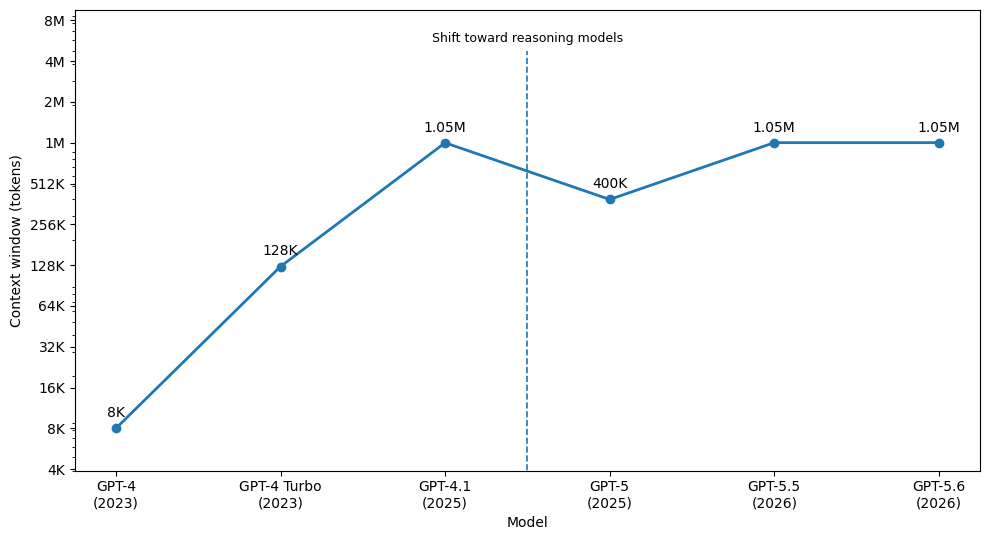

In [9]:
plt.figure(figsize=(10, 5.5))

plt.plot(
    models,
    context_windows,
    marker="o",
    linewidth=2
)

plt.yscale("log")
plt.ylim(4000, 10000000)

plt.ylabel("Context window (tokens)")
plt.xlabel("Model")

plt.yticks(
    [4096, 8192, 16384, 32768, 65536, 131072,
     262144, 524288, 1048576, 2097152, 4194304, 8388608],
    ["4K", "8K", "16K", "32K", "64K", "128K",
     "256K", "512K", "1M", "2M", "4M", "8M"]
)

plt.xticks(
    range(len(models)),
    [f"{model}\n({year})" for model, year in zip(models, years)]
)

for i, (value, label) in enumerate(zip(context_windows, labels)):
    plt.annotate(
        label,
        (i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.vlines(
    x=2.5,
    ymin=1000,
    ymax=5000000,
    linestyle="--",
    linewidth=1.2
)

plt.text(
    2.5,
    5500000,
    "Shift toward reasoning models",
    ha="center",
    va="bottom",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    "context_window.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Scegliere bene i metadata da inserire

In [38]:
date_start = '1/1/2024'
date_end = '31/12/2026'

In [39]:
# Mettere use_saved_chunks a False se si vuole cambiare i metadata, altrimenti prenderà i chunks già creati con i metadata precedenti, se presenti.

final_chunks = build_chunks_embedding(pdf_path, api_key, gemini= True, model= "gemma-3-27b-it", model_summary= "gemini-2.5-flash", # pyright: ignore[reportArgumentType]
                                      #summary_list= summary_list, use_auto_summary= False,
                                      #title= title, title_in_pdf= False,
                                      #number_at_end= False,
                                      #num_tolerance= 0.02,
                                      page_start = 1, remove_header= False, header_tolerance= 0.1 ,
                                      keep_intro= False,
                                      categoria = "Normativa",
                                      valenza = "Nazionale",
                                      #eccezione = "enti non commerciali",
                                      tipologia = "Decreto del Presidente della Repubblica",
                                      numero = "917",
                                      data = "22/12/1986",
                                      periodo = (date_start,date_end),
                                      anno= [2024,2025,2026],
                                      use_saved_chunks= True
                                      )

In [40]:
# Visualizzazione chunk finali
final_chunks

[{'text': "1. sono soggetti all'imposta sul reddito delle società: a) le società per azioni e in accomandita per azioni, le società a responsabilità limitata, le società cooperative e le società di mutua assicurazione, nonché le società europee di cui al regolamento (ce) n. 2157/2001 e le società cooperative europee di cui al regolamento (ce) n. 1435/2003 residenti nel territorio dello stato; b) gli enti pubblici e privati diversi dalle società, nonché i trust, residenti nel territorio dello stato, che hanno per oggetto esclusivo o principale l'esercizio di attività commerciali; c) gli enti pubblici e privati diversi dalle società, i trust che non hanno per oggetto esclusivo o principale l'esercizio di attività commerciale nonché gli organismi di investimento collettivo del risparmio, residenti nel territorio dello stato; d) le società e gli enti di ogni tipo, compresi i trust, con o senza personalità giuridica, non residenti nel territorio dello stato.",
  'metadata': {'document': 'de